<a href="https://colab.research.google.com/github/kingmani2003/Data-Science-Projects/blob/main/Demand_Forecasting_and_Inventory_System_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-Based Sales Demand Forecasting and Inventory Optimization


## 1. Import Libraries

In [ ]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Date Handling
from datetime import datetime

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Warnings
import warnings
warnings.filterwarnings("ignore")

### Locate your file in Google Drive

After running the cell above and authorizing Google Drive access, you can find the path to your `sales_data.csv` file. You can usually browse your Drive files from the file browser on the left sidebar of Colab. Once you find your file, right-click on it and select 'Copy path' to get the full path.

Then, replace `'YOUR_FILE_PATH_HERE'` in the next cell with the actual path.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Load Dataset

In [ ]:
# Load dataset from Google Drive
# Replace 'YOUR_FILE_PATH_HERE' with the actual path to your 'sales_data.csv' file in Google Drive
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/AiDemandForcasting/sales_data.csv')

# Display first 5 rows
display(data.head())

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


## 3. Data Exploration

In [ ]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  object 
 1   Store ID            76000 non-null  object 
 2   Product ID          76000 non-null  object 
 3   Category            76000 non-null  object 
 4   Region              76000 non-null  object 
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  object 
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  object 
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: f

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand
count,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000
mean,301.062842,88.827316,89.090645,67.726028,9.087039,0.328947,69.454029,0.200000,104.317158
std,226.510161,43.994525,162.404627,39.377899,7.475781,0.469834,40.943818,0.400003,46.964801
min,0.000000,0.000000,0.000000,4.740000,0.000000,0.000000,4.290000,0.000000,4.000000
25%,136.000000,58.000000,0.000000,31.997500,5.000000,0.000000,32.620000,0.000000,71.000000
50%,227.000000,84.000000,0.000000,64.500000,10.000000,0.000000,65.700000,0.000000,100.000000
75%,408.000000,114.000000,121.000000,95.830000,10.000000,1.000000,97.932500,0.000000,133.000000
max,2267.000000,426.000000,1616.000000,228.030000,25.000000,1.000000,261.220000,1.000000,430.000000


## 4. Data Preprocessing

In [ ]:
#Convert Date & Create Time Features
data['Date'] = pd.to_datetime(data['Date'])

data['Day'] = data['Date'].dt.day
data['Month'] = data['Date'].dt.month
data['Year'] = data['Date'].dt.year
data['DayOfWeek'] = data['Date'].dt.dayofweek
data['WeekOfYear'] = data['Date'].dt.isocalendar().week

In [ ]:
# Handle Missing Values
data.isnull().sum()

# Fill numeric columns
data.fillna(data.median(numeric_only=True), inplace=True)

# Fill categorical columns
data.fillna("Unknown", inplace=True)

In [ ]:
from sklearn.preprocessing import LabelEncoder

''' Encode Categorical Columns

Categorical columns:
Category, Region, Weather Condition, Promotion, Seasonality, Epidemic, Store ID, Product ID '''
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

categorical_cols = [
    'Store ID',
    'Product ID',
    'Category',
    'Region',
    'Weather Condition',
    'Promotion',
    'Seasonality',
    'Epidemic'
]

for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le

## 5. Feature Engineering

In [ ]:
# Feature Selection
features = [
    'Store ID',
    'Product ID',
    'Category',
    'Region',
    'Inventory Level',
    'Units Sold',
    'Units Ordered',
    'Price',
    'Discount',
    'Weather Condition',
    'Promotion',
    'Competitor Pricing',
    'Seasonality',
    'Epidemic',
    'Day',
    'Month',
    'Year',
    'DayOfWeek',
    'WeekOfYear'
]

X = data[features]
y = data['Demand']

## 6. Exploratory Data Analysis

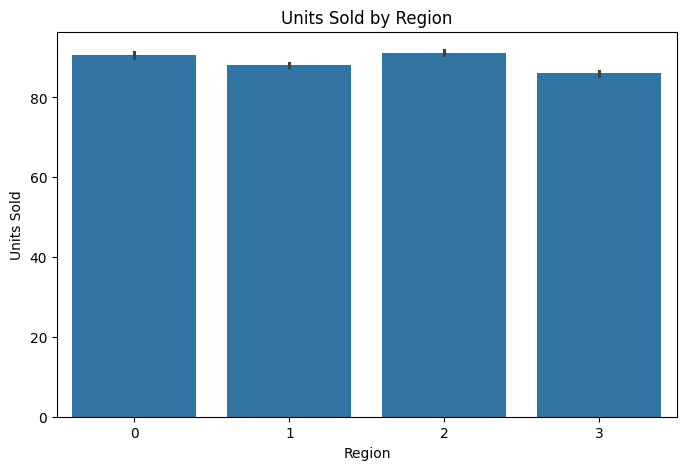

In [ ]:
# EDA Analysis
plt.figure(figsize=(8,5))
sns.barplot(x='Region', y='Units Sold', data=data)
plt.title("Units Sold by Region")
plt.show()

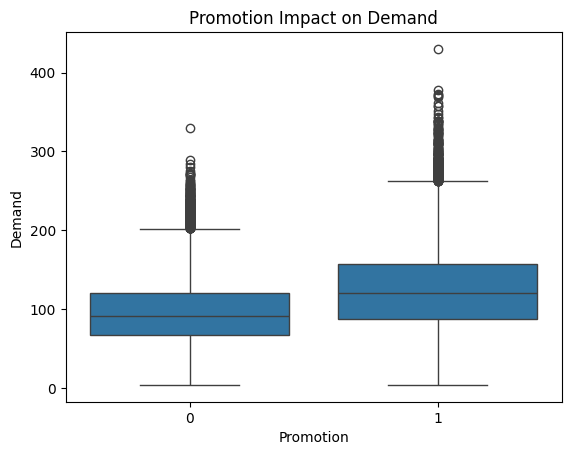

In [ ]:
sns.boxplot(x='Promotion', y='Demand', data=data)
plt.title("Promotion Impact on Demand")
plt.show()

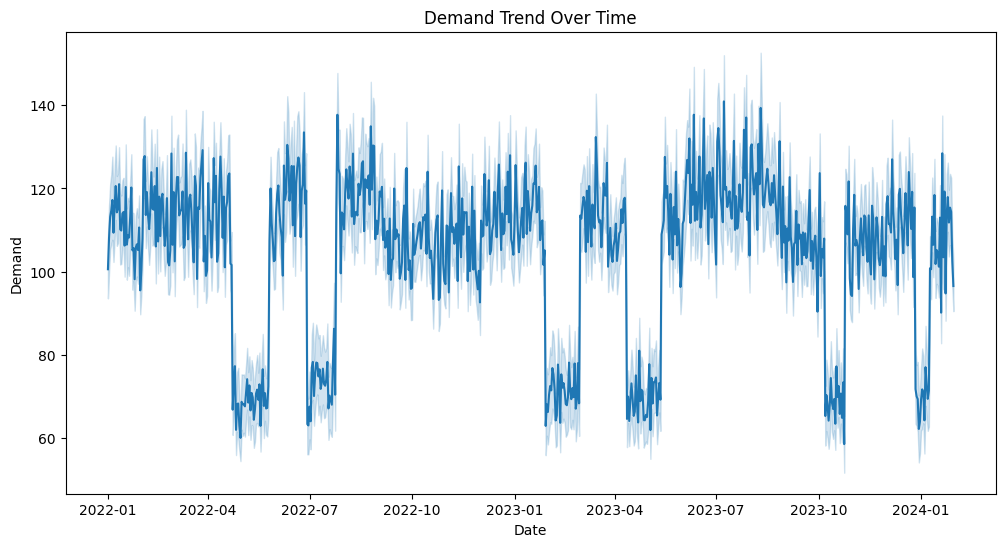

In [ ]:
plt.figure(figsize=(12,6))
sns.lineplot(data=data, x="Date", y="Demand")
plt.title("Demand Trend Over Time")
plt.show()

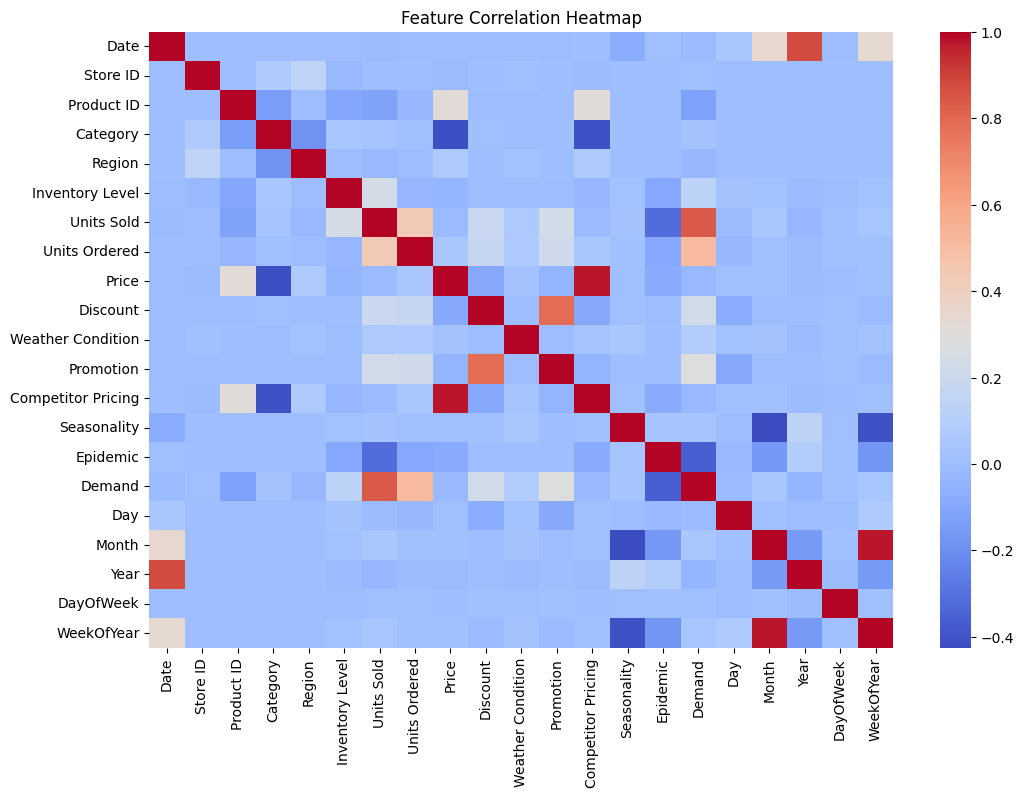

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

## 7. Model Training
*   **Sales Demand forecasting Model use**
* Linear Regression
* Random Forest
* XG Boost

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

# 1.Linear Regression Model

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

# 2. Random Forest Model

In [ ]:
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

# 3. XG Boost Model

In [ ]:
xg_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xg_model.fit(X_train, y_train)

xg_pred = xg_model.predict(X_test)

### Comparison Table Btw Linear Regression Random Forest AND  XGBoost

In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],

    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, xg_pred)
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, xg_pred))
    ],

    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, xg_pred)
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,17.076142,22.384099,0.742209
1,Random Forest,12.241163,15.918979,0.869618
2,XGBoost,11.067959,14.455443,0.892489


## 8. Model Evaluation

In [ ]:
from sklearn.metrics import r2_score

# Model evaluation
model = xg_model # Assign the best performing model
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 11.06795883178711
RMSE: 14.455442698457853
R2 Score: 0.892489492893219


In [ ]:
train_pred = model.predict(X_train)

print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, predictions))

Train R2: 0.9135828614234924
Test R2: 0.892489492893219


## 9. Demand Prediction

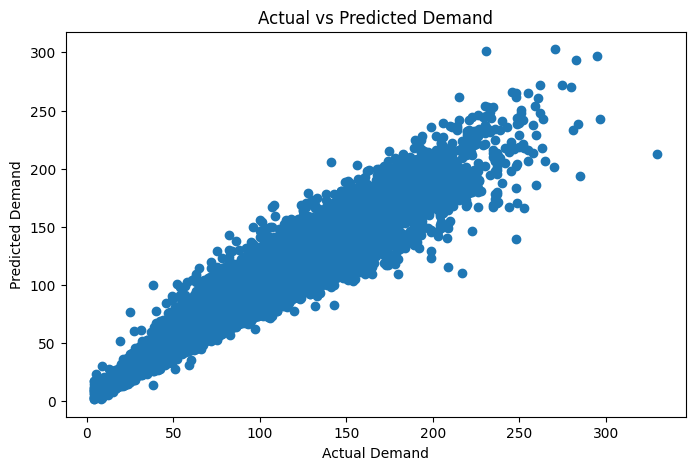

In [ ]:
# model Performance
plt.figure(figsize=(8,5))
plt.scatter(y_test, predictions)
plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted Demand")
plt.show()

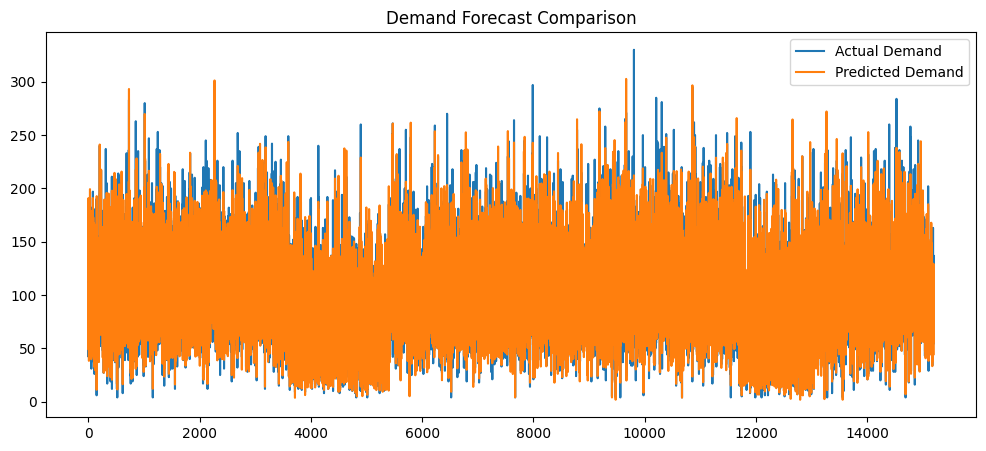

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual Demand")
plt.plot(predictions, label="Predicted Demand")
plt.legend()
plt.title("Demand Forecast Comparison")
plt.show()

In [ ]:
importance = pd.Series(model.feature_importances_, index=features)
importance.sort_values(ascending=False).head(10)

,0
Units Sold,0.614738
Promotion,0.072722
Units Ordered,0.065311
Inventory Level,0.058961
Epidemic,0.051869
Category,0.027664
Weather Condition,0.021097
Seasonality,0.013956
Price,0.011512
Region,0.009527


In [ ]:
# test new Prediction
sample = X_test.sample(1)
pred = model.predict(sample)
print("Predicted Demand:", pred[0])

Predicted Demand: 129.85321


In [ ]:
# Simple Reorder Point Formula

lead_time = 7   # days
safety_stock = 50

average_daily_demand = data['Demand'].mean()
reorder_point = (average_daily_demand * lead_time) + safety_stock

print("Reorder Point:", reorder_point)

Reorder Point: 780.2201052631578


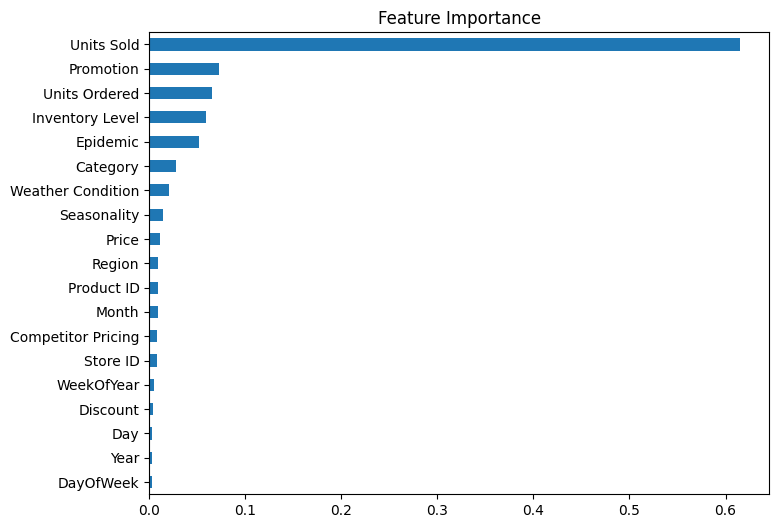

In [ ]:
# Feature Importance Business Insight
importance = pd.Series(model.feature_importances_, index=features)
importance.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance")
plt.show()

In [ ]:
# Fututre Demand Insight
future_sample = X_test.iloc[0:1]
future_prediction = model.predict(future_sample)

print("Predicted Demand:", future_prediction[0])

Predicted Demand: 114.386154


## 10. Inventory Optimization

In [ ]:
# inventory optimization logic
lead_time = 7
service_level = 1.65   # 95% confidence

avg_demand = data['Demand'].mean()
std_demand = data['Demand'].std()

safety_stock = service_level * std_demand * np.sqrt(lead_time)

reorder_point = (avg_demand * lead_time) + safety_stock

print("Safety Stock:", safety_stock)
print("Reorder Point:", reorder_point)

Safety Stock: 205.0243535549334
Reorder Point: 935.2444588180913


In [ ]:
current_inventory = data['Inventory Level'].iloc[-1]

if current_inventory < reorder_point:
    print("⚠ Reorder Required")
else:
    print("Inventory Level is Safe")

⚠ Reorder Required


In [ ]:
# Economic Order Quantity
annual_demand = data['Demand'].sum()
ordering_cost = 50
holding_cost = 5

eoq = np.sqrt((2 * annual_demand * ordering_cost) / holding_cost)

print("Optimal Order Quantity (EOQ):", eoq)

Optimal Order Quantity (EOQ): 12592.143582408835


In [ ]:
import joblib
joblib.dump(model, "demand_forecasting_model.pkl")

['demand_forecasting_model.pkl']

## 11. Conclusion

This project builds an AI-based demand forecasting system using machine learning.
The model analyzes multiple factors such as price, promotions, weather,
seasonality, and competitor pricing to predict product demand.

The system also calculates safety stock, reorder points, and economic order
quantity (EOQ) to support better inventory management decisions.

This approach helps businesses reduce stockouts, optimize inventory levels,
and improve supply chain efficiency.